In [6]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
path = "./Concat_Instruct1_1024_0020000_cross_attn_map_1"
save_path = os.path.join(path, "cross_attn_map")
os.makedirs(save_path, exist_ok=True)
data = torch.load(os.path.join(path, "Concat_Instruct1_1024_0020000.pt"))
print(type(data))

<class 'dict'>


In [8]:
print(data.keys())

dict_keys(['layer_4', 'layer_16', 'layer_35', 'logits'])


In [17]:
layer_idx = 4
cross_attn_map = torch.concat(data[f"layer_{layer_idx}"], dim=2).float().cpu()
edited_cross_attn_map = cross_attn_map[:, :, -1024:, :]
averaged_attn_map = edited_cross_attn_map.mean(dim=1)

attn_target = 4
# Only Instruct Version
def get_ref_attn(averaged_attn_map, index:int=0, instruct_num:int=120):
    if index < 4:
        # reference img
        ret = averaged_attn_map[0][:, 1024 * index:1024*(index + 1)]
    elif index  == 4:
        # prompt
        ret = averaged_attn_map[0][:, 1024 * 4:1024 * 4 + 120]
    elif index == 5:
        # Instruct Tokens
        ret = averaged_attn_map[0][:, 1024 * 4 + 120:1024 * 4 + 120 + instruct_num]
    else:
        # Tripytch
        ret = averaged_attn_map[0][:, 1024 * 4 + 120 + instruct_num + 1024 * (index - 6):1024 * 4 + 120 + instruct_num + 1024 * (index - 5)]
    return ret
single_att_map = get_ref_attn(averaged_attn_map, attn_target, 1024)
print(single_att_map.shape)

torch.Size([1024, 120])


In [15]:
a = get_ref_attn(averaged_attn_map, 4, 1024).mean(-1).reshape(32, 32).float().cpu().numpy()
b = get_ref_attn(averaged_attn_map, 5, 1024).mean(-1).reshape(32, 32).float().cpu().numpy()
print(np.abs(a-b).sum())

2.9831426e-08


2.9831426e-08


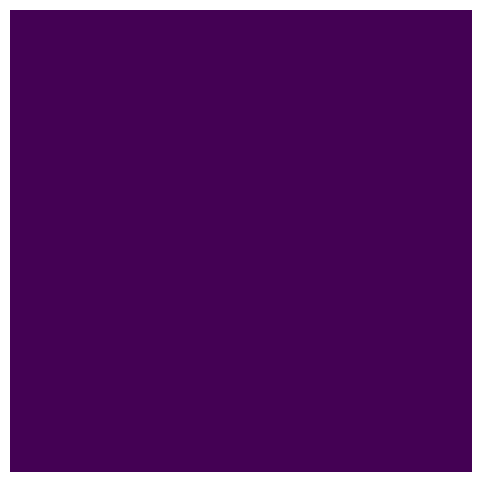

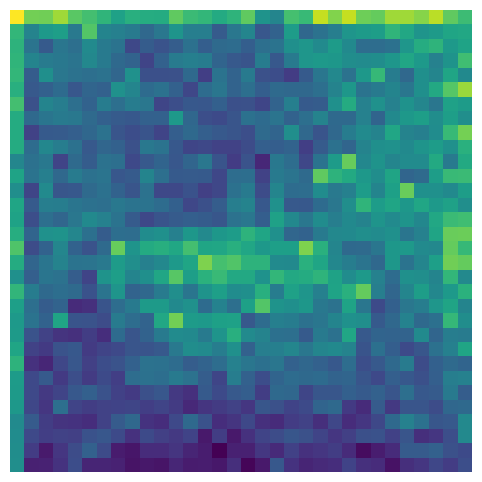

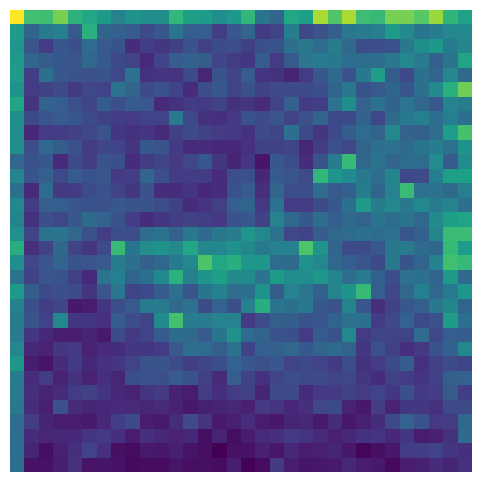

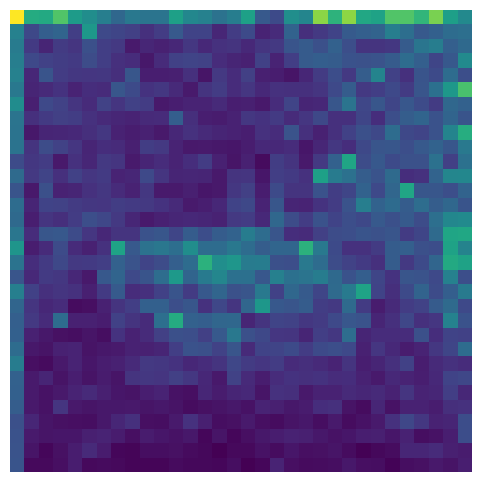

In [26]:
layer_idx = 4
attn_target = 0

cross_attn_map = torch.concat(data[f"layer_{layer_idx}"], dim=2).float().cpu()
edited_cross_attn_map = cross_attn_map[:, :, -1024:, :]
averaged_attn_map = edited_cross_attn_map.mean(dim=1)

a = get_ref_attn(averaged_attn_map, 4, 1024).mean(-1).reshape(32, 32).float().cpu().numpy()
b = get_ref_attn(averaged_attn_map, 5, 1024).mean(-1).reshape(32, 32).float().cpu().numpy()
print(np.abs(a-b).sum())
single_att_map = get_ref_attn(averaged_attn_map, attn_target, 1024)
for i in range(4):
    ratio=float(i)
    final_map = single_att_map.mean(-1).reshape(32, 32).float().cpu().numpy()** ratio
    # 1. 创建图形窗口和坐标系
    fig, ax = plt.subplots(figsize=(8, 6))

    # 2. 使用 imshow() 绘制热力图
    im = ax.imshow(final_map, cmap='viridis', interpolation='nearest')

    # # 3. 添加标题（保留）
    # ax.set_title('Cross-Attention Map')

    # 4. 关闭坐标轴的显示
    #    这会隐藏刻度、标签和边框线
    ax.axis('off')
    # .savefig("./Concat_Instruct1_120_6k_cross_attn_map_1.5x.png")
    # 5. 显示最终的图形
    
    plt.savefig(os.path.join(save_path, f"Attn_target_layer_{layer_idx}_{attn_target}_{ratio}x.png"))
    plt.show()


In [48]:
def check_feat(index:int=0):
    single_att_map = averaged_attn_map[0][:, 1024*index:1024*(index+1)]
    final_map = single_att_map.sum(-1).reshape(32, 32).float().cpu().numpy()
    return final_map

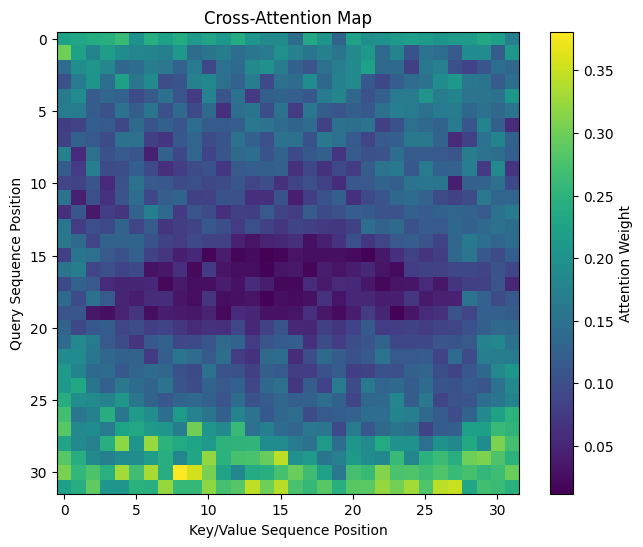

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
final = check_feat(3)
# 3. 使用 imshow() 绘制热力图
#    - numpy_array: 您的2D数据
#    - cmap: 指定颜色映射方案。'viridis', 'plasma', 'inferno', 'hot', 'jet' 都是不错的选择
#    - interpolation='nearest': 让每个单元格颜色分明，不进行平滑模糊处理，适合看attention权重
im = ax.imshow(final, cmap='viridis', interpolation='nearest')

# 4. 在右侧添加颜色渐变条
#    cbar 会自动关联到最后绘制的图像（即 im）
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Attention Weight') # 给颜色条添加一个标签

# 5. 添加标题和坐标轴标签，让图表更具可读性
ax.set_title('Cross-Attention Map')
ax.set_xlabel('Key/Value Sequence Position')
ax.set_ylabel('Query Sequence Position')

# 6. 显示最终的图形
plt.show()

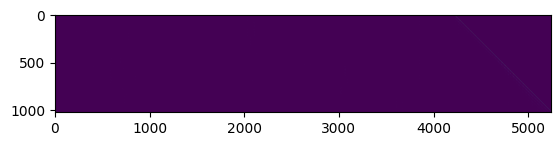

[[2.17437744e-01 2.17437744e-01 2.17437744e-01 ... 8.01086426e-02
  8.01086426e-02 8.01086426e-02]
 [3.18908691e+00 6.24656677e-02 7.34329224e-02 ... 3.09944153e-02
  3.09944153e-02 3.09944153e-02]
 [6.71386719e-01 7.24792480e-02 1.05381012e-01 ... 3.31401825e-02
  3.31401825e-02 3.31401825e-02]
 ...
 [4.69684601e-02 7.05718994e-02 8.01086426e-02 ... 9.65595245e-03
  9.65595245e-03 9.65595245e-03]
 [1.70469284e-02 1.04904175e-02 1.78813934e-02 ... 1.78710938e+02
  8.64267349e-03 8.64267349e-03]
 [3.55243683e-02 2.44379044e-02 2.13384628e-02 ... 1.98974609e+01
  1.51367188e+02 8.04662704e-03]]


In [66]:
new = averaged_attn_map[0].float().cpu().numpy()[:]*1000
plt.imshow(new)
plt.show()
print(new)

TypeError: Invalid shape (1024,) for image data

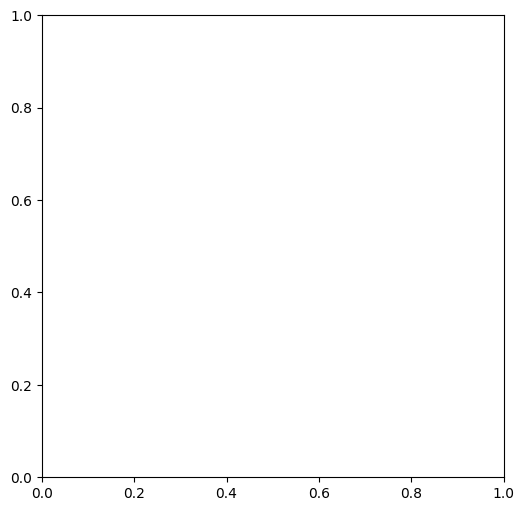

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))
# 3. 使用 imshow() 绘制热力图
#    - numpy_array: 您的2D数据
#    - cmap: 指定颜色映射方案。'viridis', 'plasma', 'inferno', 'hot', 'jet' 都是不错的选择
#    - interpolation='nearest': 让每个单元格颜色分明，不进行平滑模糊处理，适合看attention权重
im = ax.imshow(new, cmap='viridis', interpolation='nearest')

# 4. 在右侧添加颜色渐变条
#    cbar 会自动关联到最后绘制的图像（即 im）
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Attention Weight') # 给颜色条添加一个标签

# 5. 添加标题和坐标轴标签，让图表更具可读性
ax.set_title('Cross-Attention Map')
ax.set_xlabel('Key/Value Sequence Position')
ax.set_ylabel('Query Sequence Position')

# 6. 显示最终的图形
plt.show()